# Forecasting the exports volume of processed seafood in Thailand

## 1. Importing Required Libraries
In this cell, we load all the necessary Python libraries used for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`), and machine learning model creation and evaluation (`scikit-learn`).

In [2]:
# Importing standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# Importing machine learning tools
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score

## 2. Convert Excel File to CSV 
This script loads an Excel file using the `pandas` library and converts it to a CSV file.

It uses UTF-8 with BOM encoding to ensure compatibility with Excel and excludes the index column from the output.

In [3]:
# Load the .xlsx file (default sheet)
df = pd.read_excel('DATA/DGA_Main_115kV.xlsx')  # tu peux ajouter sheet_name='NomDeLaFeuille' si nécessaire

# Save as .csv
df.to_csv('DATA/DGA_Main_115kV.csv', index=False,encoding="utf-8-sig")  # index=False pour ne pas inclure la colonne d’index

## 2. Data Loading, Cleaning, and Feature Engineering
In this section, we prepare the export dataset for modeling. The process includes:
- Loading the CSV file containing monthly seafood export records from 2007 to 2024.
- Creating a datetime column by combining the Year and Month columns, enabling proper chronological sorting and time-based analysis.
- Filtering the dataset by removing rows where all product-related quantities and values are equal to zero, as these records likely represent missing or irrelevant data.
- Sorting the dataset by date to preserve temporal order.
- Generating a numerical time feature called month_num, which represents the number of months elapsed since the beginning of the dataset. This variable is used as the main input for forecasting models.

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# --- Chargement des données ---
df = pd.read_csv("DATA/DGA_Main_115kV.csv")
df = df.drop(columns=["Unnamed: 20", "Unnamed: 21"], errors='ignore')
df = df.dropna(subset=["Year Test"])
df["Year Test"] = df["Year Test"].astype(int)

# --- Suppression des lignes où toutes les colonnes clés sont à 0 ---
def supprimer_lignes_tous_zero_colonnes(df, colonnes):
    return df[~df[colonnes].eq(0.0).all(axis=1)]

colonnes_a_verifier = [
    'MFG', 'KV', 'MVA', 'Age', 'Year Test', 'O2', 'N2', 'CO2', 'CO',
    'H2', 'CH4', 'C2H2', 'C2H4', 'C2H6', 'C3H6', 'C3H8', 'TCG', 'TEMP', 'WATER'
]
df = supprimer_lignes_tous_zero_colonnes(df, colonnes_a_verifier)

# --- Caractéristique temporelle ---
df["year_num"] = df["Year Test"] - df["Year Test"].min()

# --- Calcul des ratios nécessaires ---
df["R1"] = df["CH4"] / df["H2"].replace(0, np.nan)      # CH4/H2 (R1)
df["R2"] = df["C2H2"] / df["C2H4"].replace(0, np.nan)   # C2H2/C2H4 (R2)
df["R3"] = df["C2H2"] / df["CH4"].replace(0, np.nan)    # C2H2/CH4 (R3)
df["R4"] = df["C2H6"] / df["C2H2"].replace(0, np.nan)   # C2H6/C2H2 (R4)
df["R5"] = df["C2H4"] / df["C2H6"].replace(0, np.nan)   # C2H4/C2H6 (R5)
df["Duval_Total"] = df[["CH4", "C2H2", "C2H4"]].sum(axis=1).replace(0, np.nan)

# === Fonctions de classification avec mapping vers les classes standardisées ===

# IRM (avec mapping)
def classify_IRM(row):
    R1, R2, R5 = row["R1"], row["R2"], row["R5"]
    if pd.isna(R1) or pd.isna(R2) or pd.isna(R5):
        return "Uncertain"
    if R1 < 0.1 and R5 < 0.2:
        return "PD"
    elif R1 < 0.1 and R2 > 1 and R5 > 1:
        return "PD"  # Low Energy Discharge classée PD
    elif 0.1 <= R1 <= 1 and 0.6 <= R2 <= 2.5 and R5 > 2:
        return "D1"  # High Energy Discharge → D1
    elif R5 < 1:
        return "F1"  # Thermal fault < 300°C → F1
    elif R1 > 1 and R2 < 0.1 and 1 <= R5 <= 4:
        return "T2"  # Thermal fault 300-700°C → T2
    elif R1 > 1 and R2 < 0.2 and R5 > 4:
        return "T3"  # Thermal fault > 700°C → T3
    else:
        return "Uncertain"

# DRM (mapping avec seuils stricts)
def classify_DRM(row):
    if pd.isna(row["R1"]) or pd.isna(row["R2"]) or pd.isna(row["R3"]) or pd.isna(row["R4"]):
        return "Uncertain"
    if not (row["H2"] > 100 and (row["CH4"] > 120 or row["C2H2"] > 1 or row["C2H4"] > 50)):
        return "Uncertain"

    R1, R2, R3, R4 = row["R1"], row["R2"], row["R3"], row["R4"]

    if R1 > 1 and R2 < 0.75 and R3 < 0.3 and R4 > 0.4:
        return "F1"  # Thermal Decomposition → F1
    elif R1 < 0.1 and R3 < 0.3 and R4 > 0.4:
        return "PD"
    elif 0.1 <= R1 <= 1 and R2 > 0.75 and R3 < 0.3 and R4 < 0.4:
        return "D2"  # Arcing → D2
    else:
        return "Uncertain"

# RRM (avec mapping)
def classify_RRM(row):
    if pd.isna(row["R1"]) or pd.isna(row["R2"]) or pd.isna(row["R5"]):
        return "Uncertain"
    if row[["CH4", "H2", "C2H2", "C2H4", "C2H6"]].min() <= 0:
        return "Uncertain"

    R1, R2, R5 = row["R1"], row["R2"], row["R5"]

    if 0.1 <= R1 <= 1 and R2 < 0.1 and R5 < 1:
        return "F1"  # Normal
    elif R1 < 0.1 and R2 < 0.1 and R5 < 1:
        return "PD"
    elif 0.1 <= R1 <= 1 and 0.1 <= R2 <= 3 and R5 > 3:
        return "D2"  # Arcing
    elif 0.1 <= R1 <= 1 and R2 < 0.1 and 1 <= R5 <= 3:
        return "T1"  # Low Temp Thermal
    elif R1 > 1 and R2 < 0.1 and 1 <= R5 <= 3:
        return "T2"
    elif R1 > 1 and R2 < 0.1 and R5 > 3:
        return "T3"
    else:
        return "Uncertain"

# Duval Triangle Method (DTM)
def classify_Duval_Triangle(row):
    ch4, c2h2, c2h4 = row["CH4"], row["C2H2"], row["C2H4"]
    total = ch4 + c2h2 + c2h4
    if total == 0:
        return "Uncertain"
    pct_ch4 = 100 * ch4 / total
    pct_c2h2 = 100 * c2h2 / total
    pct_c2h4 = 100 * c2h4 / total

    if pct_c2h2 > 23 and pct_c2h4 < 40:
        return "PD"
    elif pct_c2h4 > 40 and pct_c2h2 < 23:
        return "T2"
    elif 23 <= pct_c2h2 <= 50 and 20 <= pct_c2h4 <= 50:
        return "D1"  # Discharge fault
    elif pct_c2h4 < 20 and pct_c2h2 < 23:
        return "T1"
    else:
        return "Uncertain"

# Duval Pentagon Method (DPM)
def classify_Duval_Pentagon(row):
    ch4, c2h2, c2h4, h2, c2h6 = row["CH4"], row["C2H2"], row["C2H4"], row["H2"], row["C2H6"]
    total = ch4 + c2h2 + c2h4 + h2 + c2h6
    if total == 0:
        return "Uncertain"
    pct_ch4 = 100 * ch4 / total
    pct_c2h2 = 100 * c2h2 / total
    pct_c2h4 = 100 * c2h4 / total
    pct_h2 = 100 * h2 / total
    pct_c2h6 = 100 * c2h6 / total

    if pct_c2h2 > 20 and pct_h2 > 15:
        return "PD"
    elif pct_c2h4 > 40 and pct_c2h6 < 10:
        return "T1"  # Thermal fault (low energy)
    elif pct_c2h6 > 10 and pct_ch4 > 15:
        return "T3"  # Thermal fault (high energy)
    else:
        return "Uncertain"

# === Application des classifications ===
df["IRM_fault"] = df.apply(classify_IRM, axis=1)
df["DRM_fault"] = df.apply(classify_DRM, axis=1)
df["RRM_fault"] = df.apply(classify_RRM, axis=1)
df["Duval_Triangle_fault"] = df.apply(classify_Duval_Triangle, axis=1)
df["Duval_Pentagon_fault"] = df.apply(classify_Duval_Pentagon, axis=1)

# --- Vote majoritaire ---
def majority_vote(row):
    votes = [
        row["IRM_fault"],
        row["DRM_fault"],
        row["RRM_fault"],
        row["Duval_Triangle_fault"],
        row["Duval_Pentagon_fault"]
    ]
    votes = [v for v in votes if v != "Uncertain"]
    if not votes:
        return "Uncertain"
    vote_count = Counter(votes)
    # Prendre la classe la plus fréquente, en cas d'égalité, retourne une des classes (le plus commun)
    return vote_count.most_common(1)[0][0]

df["fault_majority_vote"] = df.apply(majority_vote, axis=1)

# --- Encodage numérique de la décision finale ---
label_encoder = LabelEncoder()
df["faults_index"] = label_encoder.fit_transform(df["fault_majority_vote"])

# --- Affichage du mapping pour référence ---
print("### Index des classes de défaillance (majority vote) ###")
fault_labels = {i: label for i, label in enumerate(label_encoder.classes_)}
for idx, label in fault_labels.items():
    print(f"{idx} - {label}")

# --- Tri et sauvegarde ---
if "Tr." in df.columns:
    df = df.sort_values("Tr.")
df.to_csv("DATA/DGA_Main_115kV.csv", index=False)


### Index des classes de défaillance (majority vote) ###
0 - D1
1 - D2
2 - F1
3 - PD
4 - T1
5 - T2
6 - T3
7 - Uncertain


## 3. Models

### 3.1 Model Selection

We are testing several machine learning models:

* Logistic Regression
* SVM (Support Vector Machine)
* Decision Trees
* Random Forest
* K-Nearest Neighbors (KNN)

We will apply the same training method to the different models we are going to test and compare their performance.

### 3.2 Splitting the Dataset for Cross-Validation

We use 5-fold cross-validation with stratified sampling to evaluate model performance more reliably:
* The dataset is split into 5 distinct subsets of equal size.
* For each iteration, 80% of the data is used for training and the remaining 20% is used for testing, without overlap between test sets.
* This ensures that every data point is used exactly once for testing, allowing a more robust and generalized evaluation of the model.
* Stratified splitting ensures that each fold preserves the original class distribution, which is particularly important for imbalanced datasets.

In [5]:
# Setup time series cross-validation (important to avoid data leakage in time)
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

### 3.3 Model Evaluation Methodology

In this section, we implement a comparative analysis of several machine learning models to forecast Thailand’s monthly seafood export volume. The methodology consists of the following steps:

- **Data Preparation**:
We use cleaned and time-encoded data including a numerical time index and cyclical features (month sine and cosine) to capture seasonality.

- **Validation Strategy**:
A TimeSeriesSplit with 5 folds is used to respect the chronological order of the data during training and evaluation.

- **Performance Metrics**:
For each model and fold, we compute:

    - Root Mean Squared Error (RMSE)

    - R² Score (Coefficient of Determination)
Average and standard deviation values are calculated to assess both accuracy and consistency

- **Visualization**:

    - For the last fold of each model, a scatter plot is generated comparing actual vs. predicted values.

    - A final forecasting plot displays each model’s predicted export volume from the start of the dataset up to 2030, along with the actual historical data for comparison.

This approach allows us to identify which model best captures the trends and seasonal behavior in export quantities, while also testing their generalization capability beyond the observed data.

### 3.4 Applying the Models

Classes disponibles : {0: 'D1', 1: 'D2', 2: 'F1', 3: 'PD', 4: 'T1', 5: 'T2', 6: 'T3', 7: 'Uncertain'}
Training and validating model: Logistic Regression
CV Accuracy for Logistic Regression: 0.634 ± 0.085
Training and validating model: SVC
CV Accuracy for SVC: 0.634 ± 0.085
Training and validating model: Decision Tree
CV Accuracy for Decision Tree: 0.634 ± 0.085
Training and validating model: Random Forest
CV Accuracy for Random Forest: 0.634 ± 0.085
Training and validating model: KNN
CV Accuracy for KNN: 0.379 ± 0.035


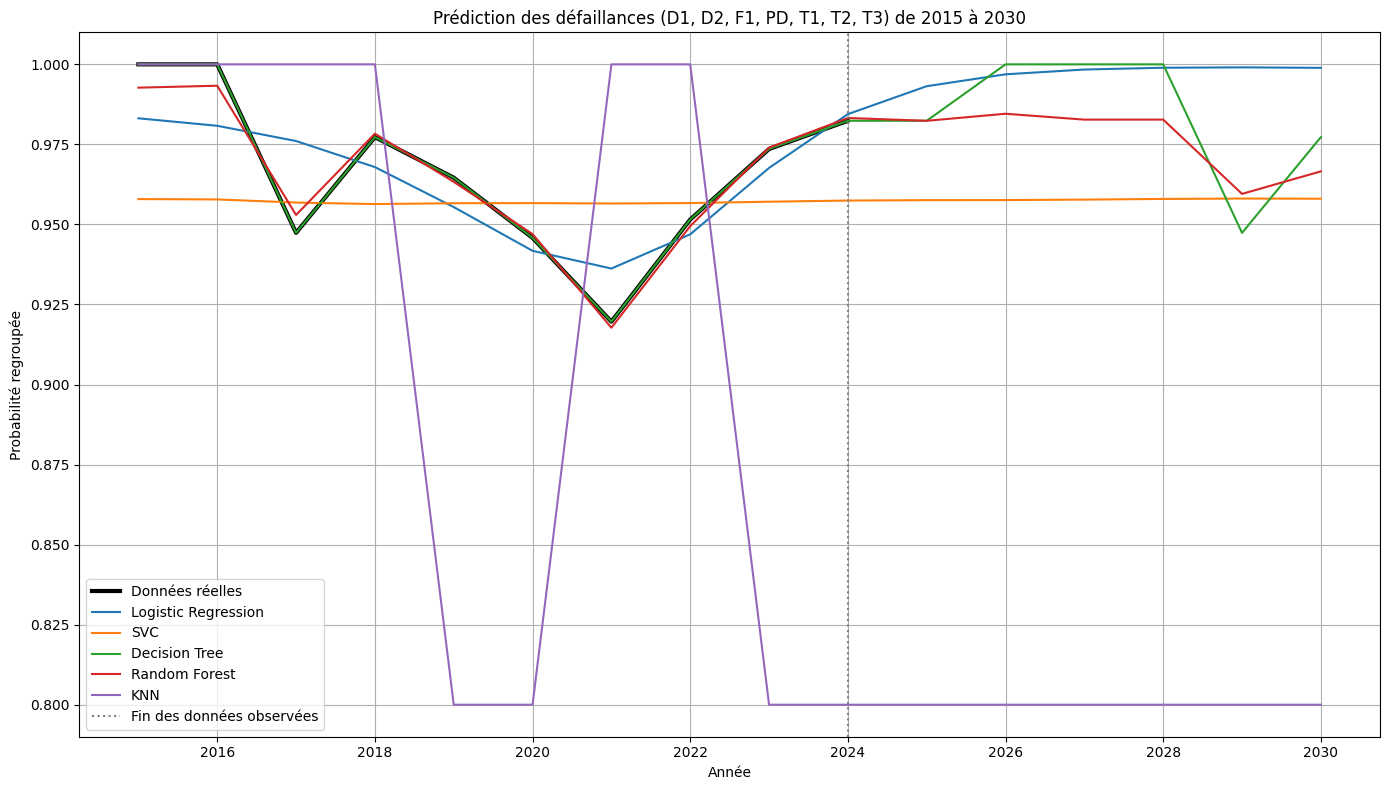

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Supposons que df est déjà préparé avec "fault_majority_vote" et sans lignes "Uncertain"
# df_ml = df[df["fault_majority_vote"] != "Uncertain"].copy()
df_ml = df[df["fault_majority_vote"] != "test"].copy()

# Encodage des labels
label_encoder = LabelEncoder()
df_ml["fault_encoded"] = label_encoder.fit_transform(df_ml["fault_majority_vote"])
fault_labels = {i: c for i, c in enumerate(label_encoder.classes_)}

# Caractéristiques temporelles
df_ml["year_num"] = df_ml["Year Test"] - df_ml["Year Test"].min()
df_ml["year_sin"] = np.sin(2 * np.pi * df_ml["Year Test"] / 12)
df_ml["year_cos"] = np.cos(2 * np.pi * df_ml["Year Test"] / 12)

# Variables explicatives et cible
X = df_ml[["year_num", "year_sin", "year_cos"]]
y = df_ml["fault_encoded"].values

# Sélection des classes d'intérêt (ajuste selon ce que tu veux prédire)
print("Classes disponibles :", fault_labels)
selected_faults_idx = list([0,1,2,3,4,5,6])  # ou [0,1,2] pour réduire
selected_faults_names = [fault_labels[i] for i in selected_faults_idx]

# Proportion réelle par année pour ces classes sélectionnées
df_ml["is_selected_fault"] = df_ml["fault_encoded"].isin(selected_faults_idx).astype(int)
real_proportion = df_ml.groupby("Year Test")["is_selected_fault"].mean()

# Préparation des années futures (2024 à 2030, à ajuster)
future_years = np.arange(df_ml["Year Test"].min(), 2031)
future_year_num = future_years - df_ml["Year Test"].min()
future_year_sin = np.sin(2 * np.pi * future_years / 12)
future_year_cos = np.cos(2 * np.pi * future_years / 12)
X_future = pd.DataFrame({
    "year_num": future_year_num,
    "year_sin": future_year_sin,
    "year_cos": future_year_cos
})

# Modèles ML
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVC": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

# Validation temporelle (time series split)
tscv = TimeSeriesSplit(n_splits=5)

# Entraînement, validation et prédiction future
plt.figure(figsize=(14, 8))
plt.plot(real_proportion.index, real_proportion.values, label="Données réelles", linewidth=3, color="black")

for name, model in models.items():
    print(f"Training and validating model: {name}")

    # Optionnel : validation croisée temporelle avec scoring (ex: accuracy)
    scores = []
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model.fit(X_train, y_train)
        scores.append(model.score(X_test, y_test))
    print(f"CV Accuracy for {name}: {np.mean(scores):.3f} ± {np.std(scores):.3f}")

    # Entraîner sur tout le dataset
    model.fit(X, y)

    # Prédiction pour les années futures
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_future)
        # Somme des probabilités des classes sélectionnées
        grouped_proba = proba[:, selected_faults_idx].sum(axis=1)
    else:
        preds = model.predict(X_future)
        grouped_proba = np.isin(preds, selected_faults_idx).astype(int)

    plt.plot(future_years, grouped_proba, label=name)

# Ligne verticale indiquant fin des données observées
plt.axvline(x=df_ml["Year Test"].max(), color="grey", linestyle=":", label="Fin des données observées")
plt.xlabel("Année")
plt.ylabel("Probabilité regroupée")
plt.title(f"Prédiction des défaillances ({', '.join(selected_faults_names)}) de {df_ml['Year Test'].min()} à 2030")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 4. Hyperparameter Tuning 
In this section, we re-evaluate the five machine learning models using hyperparameter optimization to improve their performance.

### 4.1  Grid Search Hyperparameter Tuning for Regression Models

The goal is to determine the best combination of hyperparameters for each model using grid search combined with time series cross-validation `(TimeSeriesSplit)`, which ensures that the temporal order of the data is respected during training and validation.

**Key elements of this process:**
- A hyperparameter grid is defined for each model (except Linear Regression, which has no tunable hyperparameters).

- For each model, GridSearchCV tests all combinations of hyperparameters using 5-fold time series CV and evaluates them based on negative mean squared error.

- The best-performing model configuration (lowest RMSE) is saved for each algorithm.

- A summary table is printed showing:

    - The best hyperparameter set (Best Params)

    - The corresponding cross-validated RMSE (Best CV RMSE)

This tuning step aims to maximize the predictive accuracy of each model before proceeding to final evaluations and future forecasting.

In [22]:
# --- Assume df, X and y are already defined from previous steps ---
# df must include: 'year_num', 'year_sin', 'year_cos', 'TCG'

# Cross-validation strategy
tscv = TimeSeriesSplit(n_splits=5)

# Hyperparameter grids
param_grids = {
    "Linear Regression": {},  # No tuning necessary
    
    "SVR": {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'epsilon': [0.01, 0.1, 0.5]
    },
    
    "Decision Tree": {
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    
    "KNN": {
        'n_neighbors': [3, 5, 7, 10],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    }
}

# Models to test
models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

best_models = {}
results = {}

# Loop through each model
for name, model in models.items():
    print(f"\n=== Hyperparameter tuning for {name} ===")
    param_grid = param_grids.get(name, {})
    
    if not param_grid:
        print("No hyperparameters to tune for this model.")
        model.fit(X, y)
        best_models[name] = model
        continue
    
    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X, y)
    
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    best_rmse = (-grid_search.best_score_) ** 0.5
    
    print(f"Best params for {name}: {grid_search.best_params_}")
    print(f"Best CV RMSE: {best_rmse:.4f}")
    
    results[name] = {
        "Best Params": grid_search.best_params_,
        "Best CV RMSE": best_rmse
    }

# Summary of results
summary_df = pd.DataFrame(results).T
print("\n=== Summary of Hyperparameter Tuning Results ===")
print(summary_df)


=== Hyperparameter tuning for Linear Regression ===
No hyperparameters to tune for this model.

=== Hyperparameter tuning for SVR ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params for SVR: {'C': 10, 'epsilon': 0.5, 'gamma': 'scale'}
Best CV RMSE: 414.1423

=== Hyperparameter tuning for Decision Tree ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV RMSE: 399.6138

=== Hyperparameter tuning for Random Forest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params for Random Forest: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Best CV RMSE: 399.1592

=== Hyperparameter tuning for KNN ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params for KNN: {'n_neighbors': 10, 'p': 1, 'weights': 'uniform'}
Best CV RMSE: 412.7494

=== Summary of Hyperparameter Tuning Resu

### 4.2  Evaluation of Optimized Models and Long-Term Forecasting

In this section, we re-evaluate all five machine learning models using their best hyperparameter configurations, obtained previously through grid search. Each model is validated using a 5-fold time series cross-validation to compute its predictive accuracy and stability.

**Methodology**:
- We use the same input features (month_num, month_sin, month_cos) and target (Grand Total Quantity (Tons)).

- For each model:

    - The model is trained and evaluated across 5 consecutive folds.

    - Performance metrics include: RMSE (Root Mean Squared Error) and R² Score (Coefficient of Determination)

    - A scatter plot is generated for the final fold, comparing actual vs. predicted values.

- A summary table of average performance is printed for model comparison.

- Finally, all models are re-trained on the full dataset and used to forecast seafood export volumes up to *December 2030*.

The results are visualized in a single plot showing each model's predicted trend alongside the historical data.

This step highlights how the tuned models perform under realistic, temporally ordered validation, and assesses their ability to extrapolate future export trends.


=== Linear Regression ===

--- Fold 1 ---
RMSE: 388.4450
R²: -0.0650

--- Fold 2 ---
RMSE: 376.5993
R²: 0.0013

--- Fold 3 ---
RMSE: 387.9186
R²: -0.0440

--- Fold 4 ---
RMSE: 390.7501
R²: -0.0024

--- Fold 5 ---
RMSE: 456.4143
R²: -0.0004


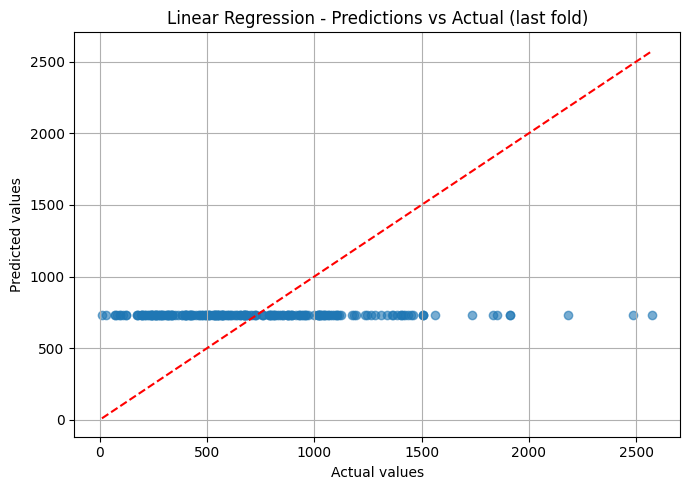


=== SVR ===

--- Fold 1 ---
RMSE: 395.7309
R²: -0.1053

--- Fold 2 ---
RMSE: 379.9407
R²: -0.0165

--- Fold 3 ---
RMSE: 394.4200
R²: -0.0793

--- Fold 4 ---
RMSE: 410.2394
R²: -0.1049

--- Fold 5 ---
RMSE: 482.4394
R²: -0.1178


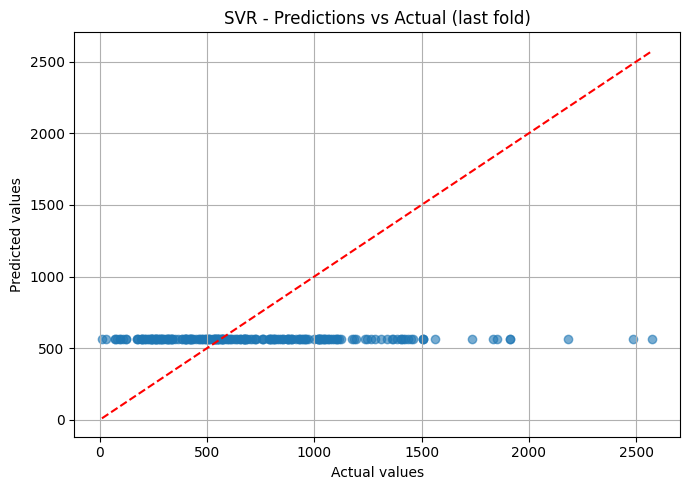


=== Decision Tree ===

--- Fold 1 ---
RMSE: 378.5622
R²: -0.0115

--- Fold 2 ---
RMSE: 378.2729
R²: -0.0076

--- Fold 3 ---
RMSE: 386.0169
R²: -0.0338

--- Fold 4 ---
RMSE: 390.9657
R²: -0.0035

--- Fold 5 ---
RMSE: 457.9002
R²: -0.0070


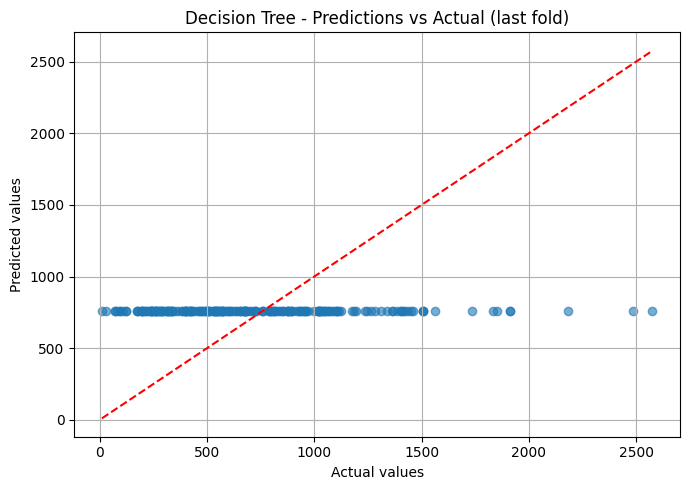


=== Random Forest ===

--- Fold 1 ---
RMSE: 378.3342
R²: -0.0102

--- Fold 2 ---
RMSE: 377.9969
R²: -0.0061

--- Fold 3 ---
RMSE: 384.9058
R²: -0.0278

--- Fold 4 ---
RMSE: 390.8141
R²: -0.0027

--- Fold 5 ---
RMSE: 459.2590
R²: -0.0129


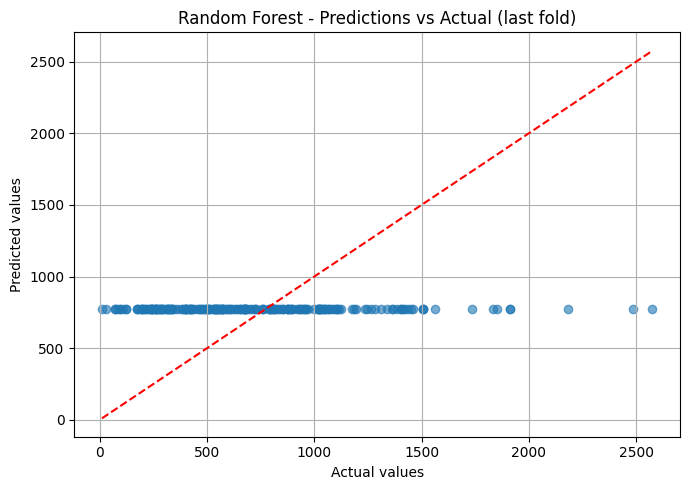


=== KNN ===

--- Fold 1 ---
RMSE: 376.5204
R²: -0.0006

--- Fold 2 ---
RMSE: 394.7900
R²: -0.0975

--- Fold 3 ---
RMSE: 423.4464
R²: -0.2440

--- Fold 4 ---
RMSE: 407.8965
R²: -0.0923

--- Fold 5 ---
RMSE: 456.6148
R²: -0.0013


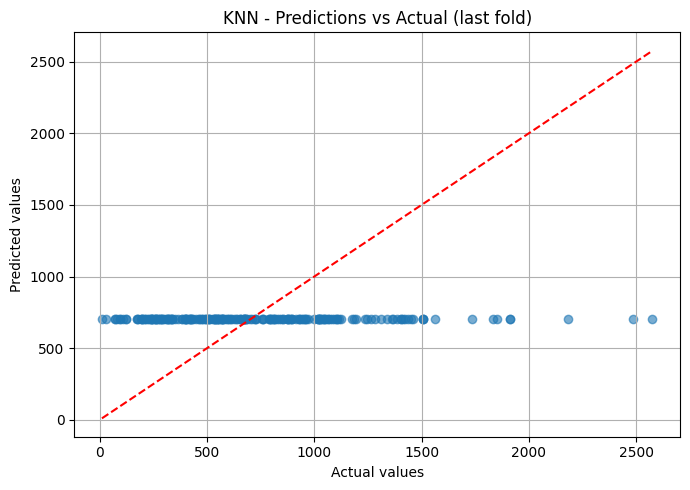


=== Summary of Results ===
                   RMSE mean  RMSE std  R² mean  R² std
Linear Regression   400.0255   28.6189  -0.0221  0.0273
SVR                 412.5541   36.2348  -0.0847  0.0364
Decision Tree       398.3436   30.1579  -0.0127  0.0109
Random Forest       398.2620   30.8619  -0.0120  0.0087
KNN                 411.8536   27.1780  -0.0871  0.0890


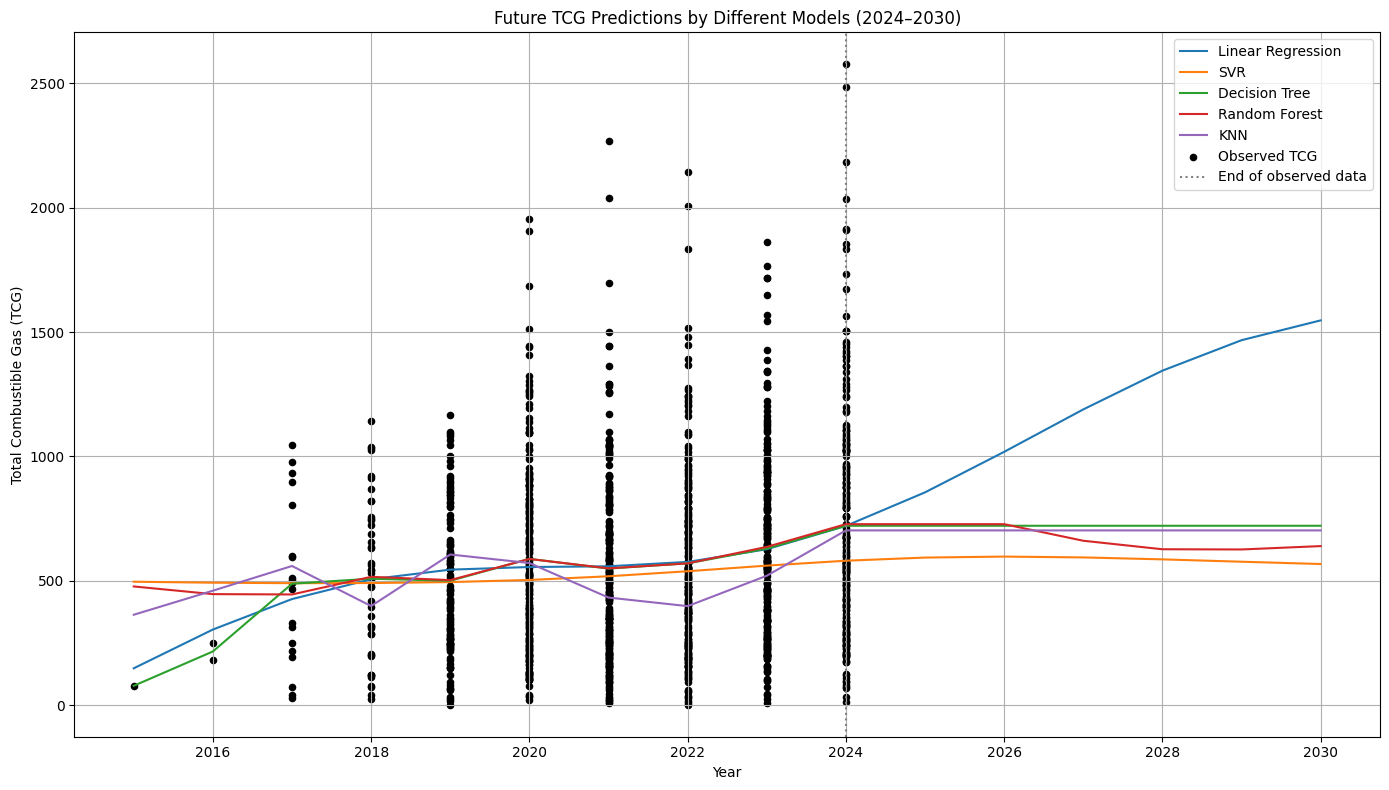

In [24]:
# --- Feature engineering ---
df["year_sin"] = np.sin(2 * np.pi * df["Year Test"] / 12)
df["year_cos"] = np.cos(2 * np.pi * df["Year Test"] / 12)

X = df[["year_num", "year_sin", "year_cos"]]
y = df["TCG"].values  # Target: Total Combustible Gas

# --- Models to Evaluate ---

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(C= 10, epsilon= 0.5, gamma= 'scale'),
    "Decision Tree": DecisionTreeRegressor(max_depth= 5, min_samples_leaf= 1, min_samples_split= 2),
    "Random Forest": RandomForestRegressor(max_depth= 5, min_samples_leaf= 4, min_samples_split= 10, n_estimators= 50),
    "KNN": KNeighborsRegressor(n_neighbors= 10, p= 1, weights= 'uniform')
}

tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in models.items():
    rmse_scores = []
    r2_scores = []
    print(f"\n=== {name} ===")
    
    for i, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        rmse_scores.append(rmse)
        r2_scores.append(r2)
        
        print(f"\n--- Fold {i+1} ---")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")
        
        # Plot last fold predictions
        if i == tscv.get_n_splits() - 1:  
            plt.figure(figsize=(7, 5))
            plt.scatter(y_val, y_pred, alpha=0.6)
            plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
            plt.xlabel("Actual values")
            plt.ylabel("Predicted values")
            plt.title(f"{name} - Predictions vs Actual (last fold)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    
    results[name] = {
        "RMSE mean": np.mean(rmse_scores),
        "RMSE std": np.std(rmse_scores),
        "R² mean": np.mean(r2_scores),
        "R² std": np.std(r2_scores)
    }

# --- Summary of results ---
summary_df = pd.DataFrame(results).T.round(4)
print("\n=== Summary of Results ===")
print(summary_df)

# --- Future prediction using all available data ---
future_years = np.arange(df["Year Test"].min(), 2031)
future_year_num = future_years - df["Year Test"].min()
future_year_sin = np.sin(2 * np.pi * future_years / 12)
future_year_cos = np.cos(2 * np.pi * future_years / 12)

X_future = pd.DataFrame({
    "year_num": future_year_num,
    "year_sin": future_year_sin,
    "year_cos": future_year_cos
})

plt.figure(figsize=(14, 8))
for name, model in models.items():
    model.fit(X, y)
    y_pred_future = model.predict(X_future)
    plt.plot(future_years, y_pred_future, label=name)

plt.scatter(df["Year Test"], y, label="Observed TCG", color="black", s=20)
plt.axvline(x=2024, color="grey", linestyle=":", label="End of observed data")
plt.xlabel("Year")
plt.ylabel("Total Combustible Gas (TCG)")
plt.title("Future TCG Predictions by Different Models (2024–2030)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Final Forecast Using Random Forest with All Product Features

In this section, we build a comprehensive forecasting model using Random Forest Regressor with both temporal features and product-specific export quantities as inputs. The objective is to improve the accuracy of total export volume predictions (Grand Total Quantity (Tons)) by integrating historical patterns from multiple seafood categories.

### 5.1 Random Forest with Full Feature Set

In this block, we train and evaluate a Random Forest Regressor using a rich set of features that combine temporal indicators and historical export volumes for all major seafood product categories.

**Workflow:**
- The input matrix `X` includes:

    - Time-based features: `month_num`, `month_sin`, `month_cos`

    - Export quantities for 25 specific product categories (e.g., shrimp, fish, canned products).

- The target `y` is the total export quantity `(Grand Total Quantity (Tons))`.

- We evaluate the model using 5-fold time series cross-validation, computing the average and standard deviation of RMSE.

- After cross-validation, the model is retrained on the entire dataset to prepare for future forecasting.

This approach aims to improve the prediction of total seafood exports by leveraging trends observed in individual product lines.

In [ ]:
# --- Feature engineering ---
df["year_sin"] = np.sin(2 * np.pi * df["Year Test"] / 12)
df["year_cos"] = np.cos(2 * np.pi * df["Year Test"] / 12)

X = df[["year_num", "year_sin", "year_cos"]]

# Model

based_model = RandomForestRegressor(max_depth= 5, min_samples_leaf= 4, min_samples_split= 10, n_estimators= 50)

O2= based_model
N2= based_model
CO2= based_model
CO= based_model
H2= based_model
CH4= based_model
C2H2= based_model
C2H4= based_model
C2H6= based_model
C3H6= based_model
C3H8= based_model
TCG= based_model
TEMP= based_model
WATER= based_model

# Temporal cross validation
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

# ---------- scenario for 2025 ----------
# Create range
all_months = pd.date_range(start=df['month'].min(), end="2025-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)
mask = all_months != pd.to_datetime("2013-07-01")

all_months = all_months[mask]
all_month_nums = all_month_nums[mask]
all_month_sin = all_month_sin[mask]
all_month_cos = all_month_cos[mask]

# Dataframe creation for complete prediction
X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
})

def prediction(model,y):
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_val)
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        rmse_scores.append(rmse)


    model.fit(X, y)

    y_all_pred = model.predict(X_all)

    return y_all_pred

prediction_chilled_Shrimp = prediction(model_Chilled_Frozen_Fresh_Shrimp, df['Chilled/Frozen Fresh Shrimp Quantity (Tons)'].values)
prediction_Shrimp_Airtight = prediction(model_Shrimp_Airtight, df['Shrimp in Airtight Containers Quantity (Tons)'].values)
prediction_Shrimp_Processed = prediction(model_Preserved_Processed_Shrimp, df['Preserved or Processed Shrimp Quantity (Tons)'].values)
prediction_Shrimp = prediction(model_Shrimp,df['Shrimp Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fresh_Squid = prediction(model_Chilled_Frozen_Fresh_Squid, df['Chilled/Frozen Fresh Squid Quantity (Tons)'].values)
prediction_Dried_Squid = prediction(model_Dried_Squid, df['Dried Squid Quantity (Tons)'].values)
prediction_Processed_Preserved_Squid = prediction(model_Processed_Preserved_Squid, df['Processed or Preserved Squid Quantity (Tons)'].values)
prediction_Squid = prediction(model_Squid, df['Squid Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fresh_Fish = prediction(model_Chilled_Frozen_Fresh_Fish, df['Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fish_Fillets = prediction(model_Chilled_Frozen_Fish_Fillets, df['Chilled/Frozen Fish Fillets Quantity (Tons)'].values)
prediction_Dried_Fish = prediction(model_Dried_Fish, df['Dried Fish Quantity (Tons)'].values)
prediction_Live_Fish_Fish_Breeding_Stock = prediction(model_Live_Fish_Fish_Breeding_Stock, df['Dried Fish Quantity (Tons)'].values)
prediction_Fish = prediction(model_Fish,df['Fish Quantity (Tons)'].values)
prediction_Canned_Tuna = prediction(model_Canned_Tuna,df['Canned Tuna Quantity (Tons)'].values)
prediction_Canned_Sardines = prediction(model_Canned_Sardines,df['Canned Sardines Quantity (Tons)'].values)
prediction_Other_Canned_Fish = prediction(model_Other_Canned_Fish,df['Other Canned Fish Quantity (Tons)'].values)
prediction_Canned_Crab = prediction(model_Canned_Crab,df['Canned Crab Quantity (Tons)'].values)
prediction_Other_Canned_Seafood = prediction(model_Other_Canned_Seafood,df['Other Canned Seafood Quantity (Tons)'].values)
prediction_Canned_Products = prediction(model_Canned_Products,df['Canned Products Quantity (Tons)'].values)
prediction_Canned_Dog_Cat_Food = prediction(model_Canned_Dog_Cat_Food,df['Canned Dog and Cat Food Quantity (Tons)'].values)
prediction_Processed_Seafood_Products = prediction(model_Processed_Seafood_Products,df['Processed Seafood Products Quantity (Tons)'].values)
prediction_Processed_Tuna_Products = prediction(model_Processed_Tuna_Products,df['Processed Tuna Products Quantity (Tons)'].values)
prediction_Preserved_Processed_Crab  = prediction(model_Preserved_Processed_Crab,df['Preserved or Processed Crab Quantity (Tons)'].values)
prediction_Other_Processed_Seafood_Products  = prediction(model_Other_Processed_Seafood_Products,df['Other Processed Seafood Products Quantity (Tons)'].values)
prediction_Other_Fishery_Products = prediction(model_Other_Fishery_Products,df['Other Fishery Products Quantity (Tons)'].values)

X_Future = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
    'Chilled/Frozen Fresh Shrimp Quantity (Tons)':prediction_chilled_Shrimp,
    'Shrimp in Airtight Containers Quantity (Tons)':prediction_Shrimp_Airtight,
    'Preserved or Processed Shrimp Quantity (Tons)':prediction_Shrimp_Processed,
    'Shrimp Quantity (Tons)':prediction_Shrimp,
    'Chilled/Frozen Fresh Squid Quantity (Tons)':prediction_Chilled_Frozen_Fresh_Squid,
    'Dried Squid Quantity (Tons)':prediction_Dried_Squid,
    'Processed or Preserved Squid Quantity (Tons)':prediction_Processed_Preserved_Squid,
    'Squid Quantity (Tons)':prediction_Squid,
    'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)':prediction_Chilled_Frozen_Fresh_Fish,
    'Chilled/Frozen Fish Fillets Quantity (Tons)':prediction_Chilled_Frozen_Fish_Fillets,
    'Dried Fish Quantity (Tons)':prediction_Dried_Fish,
    'Live Fish and Fish Breeding Stock Quantity (Tons)':prediction_Live_Fish_Fish_Breeding_Stock,
    'Fish Quantity (Tons)':prediction_Fish,
    'Canned Tuna Quantity (Tons)':prediction_Canned_Tuna,
    'Canned Sardines Quantity (Tons)':prediction_Canned_Sardines,
    'Other Canned Fish Quantity (Tons)':prediction_Other_Canned_Fish,
    'Canned Crab Quantity (Tons)':prediction_Canned_Crab,
    'Other Canned Seafood Quantity (Tons)':prediction_Other_Canned_Seafood,
    'Canned Products Quantity (Tons)':prediction_Canned_Products,
    'Canned Dog and Cat Food Quantity (Tons)':prediction_Canned_Dog_Cat_Food,
    'Processed Seafood Products Quantity (Tons)':prediction_Processed_Seafood_Products,
    'Processed Tuna Products Quantity (Tons)':prediction_Processed_Tuna_Products,
    'Preserved or Processed Crab Quantity (Tons)':prediction_Preserved_Processed_Crab ,
    'Other Processed Seafood Products Quantity (Tons)':prediction_Other_Processed_Seafood_Products ,
    'Other Fishery Products Quantity (Tons)':prediction_Other_Fishery_Products
})

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

RMSE CV: Moyenne = 1953.92, Écart-type = 2206.98


### 5.2 Forecasting Total Exports with Predicted Category-Level Inputs

In this block, we use the trained Random Forest model to forecast total export quantities up to December 2025, using the predicted values of each product category as inputs.

**Key steps:**
- Future months from the dataset start until end of 2025 are generated and encoded as temporal features (`month_num`, `month_sin`, `month_cos`).

- Forecast inputs are taken from the previously built `X_Future` dataset, which includes predicted export quantities for each product type.

- The model predicts the total export volume (`y_all_pred`) based on these inputs.

- A final line plot shows:

    - Historical data in blue dashed line.

    - Forecasted total exports in green dashed line.

    - A vertical marker at *December 2024*, which separates observed and forecasted periods.

This visualization provides a forward-looking estimate of how Thailand’s total seafood exports might evolve under current trends across individual product segments.

RMSE CV: Moyenne = 9550.81, Écart-type = 1688.18


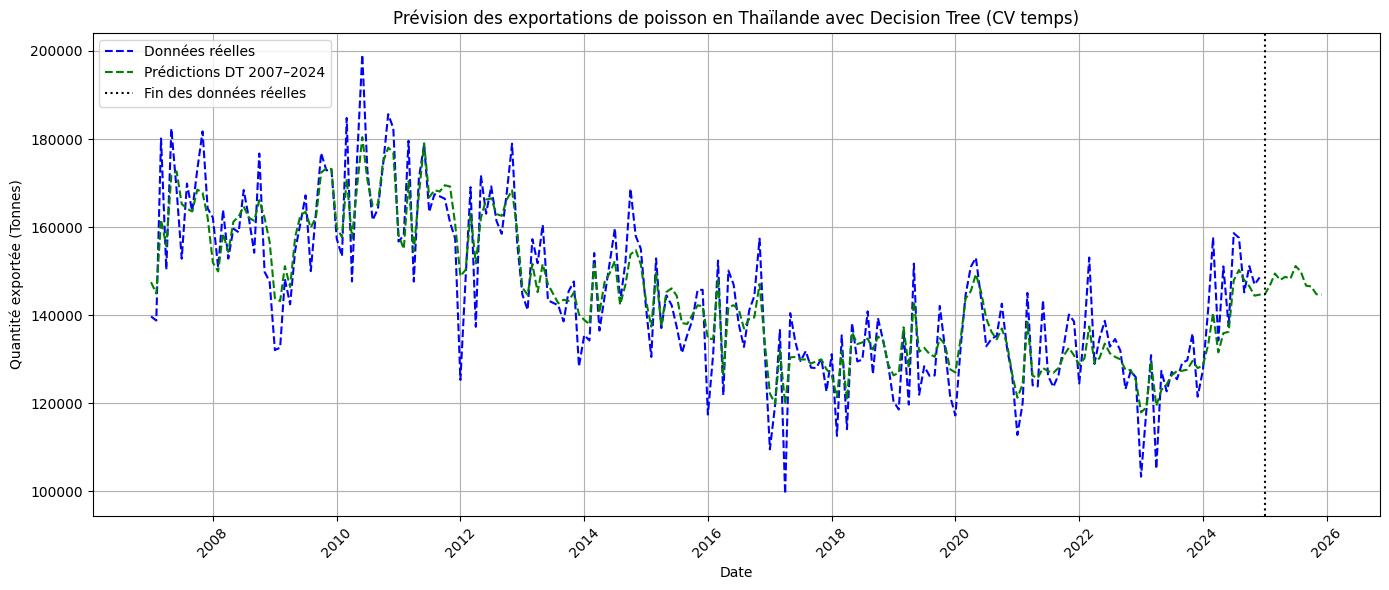

In [53]:
# features and target
X = df[['month_num', 'month_sin', 'month_cos', 
        'Chilled/Frozen Fresh Shrimp Quantity (Tons)',
        'Shrimp in Airtight Containers Quantity (Tons)',
        'Preserved or Processed Shrimp Quantity (Tons)',
        'Shrimp Quantity (Tons)',
        'Chilled/Frozen Fresh Squid Quantity (Tons)',
        'Dried Squid Quantity (Tons)',
        'Processed or Preserved Squid Quantity (Tons)',
        'Squid Quantity (Tons)',
        'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)',
        'Chilled/Frozen Fish Fillets Quantity (Tons)',
        'Dried Fish Quantity (Tons)',
        'Live Fish and Fish Breeding Stock Quantity (Tons)',
        'Fish Quantity (Tons)',
        'Canned Tuna Quantity (Tons)',
        'Canned Sardines Quantity (Tons)',
        'Other Canned Fish Quantity (Tons)',
        'Canned Crab Quantity (Tons)',
        'Other Canned Seafood Quantity (Tons)',
        'Canned Products Quantity (Tons)',
        'Canned Dog and Cat Food Quantity (Tons)',
        'Processed Seafood Products Quantity (Tons)',
        'Processed Tuna Products Quantity (Tons)',
        'Preserved or Processed Crab Quantity (Tons)',
        'Other Processed Seafood Products Quantity (Tons)',
        'Other Fishery Products Quantity (Tons)',
        ]]
y = df['Grand Total Quantity (Tons)'].values

# DecisionTree
model = RandomForestRegressor(max_depth= 20, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200)

# Temporal cross validation
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

# Training
model.fit(X, y)

# Months generation to 2025-12
all_months = pd.date_range(start=df['month'].min(), end="2025-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

mask = all_months != pd.to_datetime("2013-07-01")

all_months = all_months[mask]
all_month_nums = all_month_nums[mask]
all_month_sin = all_month_sin[mask]
all_month_cos = all_month_cos[mask]


# Forecasting
y_all_pred = model.predict(X_Future)

# Display
plt.figure(figsize=(14, 6))
plt.plot(df['month'], y, label="Données réelles",  linestyle="--",color='blue')
plt.plot(all_months, y_all_pred, label="Prédictions DT 2007–2024", linestyle="--", color='green')
plt.axvline(x=pd.to_datetime("2024-12-31"), color='black', linestyle=':', label='Fin des données réelles')
plt.xlabel("Date")
plt.ylabel("Quantité exportée (Tonnes)")
plt.title("Prévision des exportations de poisson en Thaïlande avec Decision Tree (CV temps)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()